In [2]:
from diffusion_brain_alignment.data.things_monkey_ephys import (
    data_dir,
    area_channels,
    download,
    download_images,
    sample_trials,
    load_stimuli,
    load_brain_response,
)
from diffusion_brain_alignment.models.stable_diffusion import extract_features

trials = sample_trials(monkey="monkeyF", split="train", n_samples=50)
responses = load_brain_response(trials, roi="V4")
images = load_stimuli(trials)
features = extract_features(images, 0.85)

/teamspace/studios/this_studio/diffusion-brain-alignment/data/things/images_THINGS.zip


/teamspace/studios/this_studio/diffusion-brain-alignment/.venv/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [3]:
responses.shape, features.shape

((50, 192), torch.Size([50, 1280]))

RSA Alignment Score (Spearman's rho-a): 0.0830


(<Figure size 200x200 with 1 Axes>,
 array([[<Axes: >]], dtype=object),
 {-1: {}, 0: {'image': <matplotlib.image.AxesImage at 0x7d4e58710b80>}})

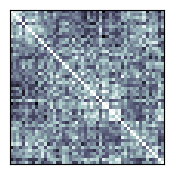

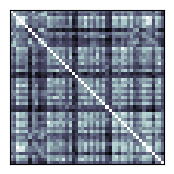

In [4]:
import rsatoolbox

bio_dataset = rsatoolbox.data.Dataset(responses)
diff_dataset = rsatoolbox.data.Dataset(features)

bio_rdm = rsatoolbox.rdm.calc_rdm(bio_dataset, method='correlation')
diff_rdm = rsatoolbox.rdm.calc_rdm(diff_dataset, method='correlation')

similarity_score = rsatoolbox.rdm.compare(bio_rdm, diff_rdm, method='rho-a')

print(f"RSA Alignment Score (Spearman's rho-a): {similarity_score[0][0]:.4f}")

rsatoolbox.vis.show_rdm(bio_rdm)
rsatoolbox.vis.show_rdm(diff_rdm)